# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

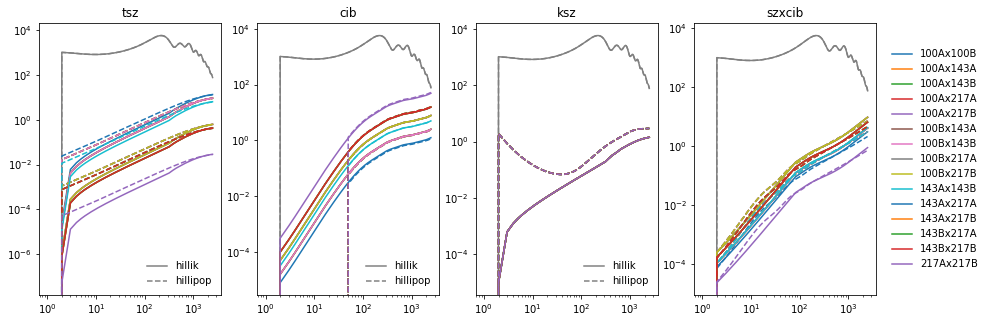

In [31]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

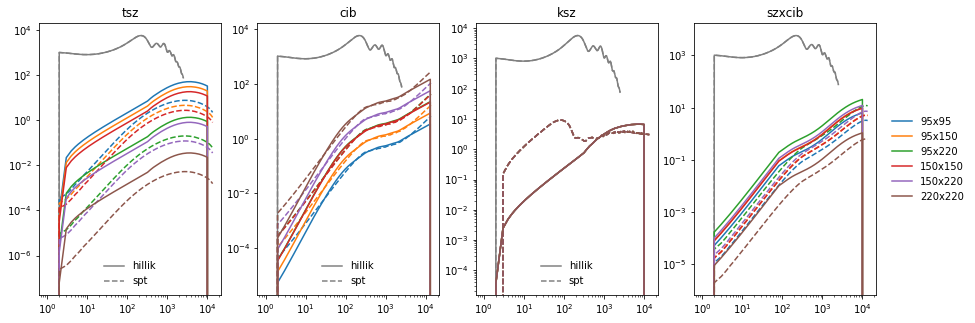

In [30]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

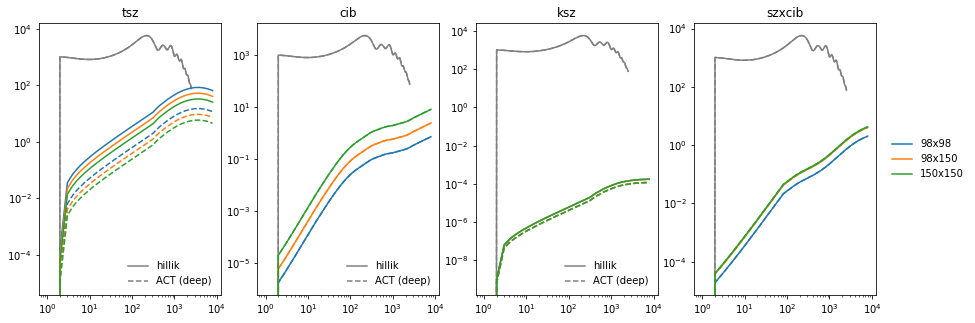

In [28]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

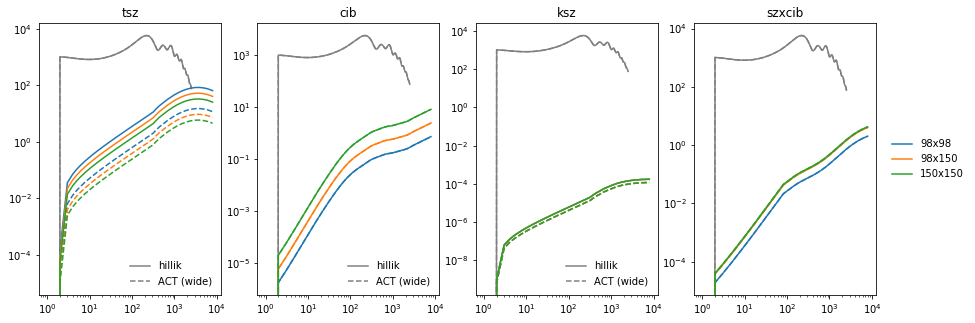

In [29]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

## Each survey

In [2]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 118281  79113  88521  89152 
hillik_spt: 311963  279952  260087  324458 
hillik_act: 396278  282581  349881  368368 


                         hillik_plk                 hillik_spt                 hillik_act
ombh2           =  0.022229 +/- 0.000207  |   0.023310 +/- 0.001950  |   0.021550 +/- 0.000667
omch2           =  0.119053 +/- 0.002020  |   0.115539 +/- 0.015391  |   0.131488 +/- 0.007648
theta           =  1.040820 +/- 0.000459  |   1.039740 +/- 0.006395  |   1.040865 +/- 0.001424
tau             =  0.056231 +/- 0.006813  |   0.055032 +/- 0.006748  |   0.054899 +/- 0.007067
ns              =  0.963648 +/- 0.006166  |   0.979475 +/- 0.019694  |   0.988549 +/- 0.011665
logA            =  3.042788 +/- 0.014606  |   2.991056 +/- 0.074133  |   3.064085 +/- 0.054270


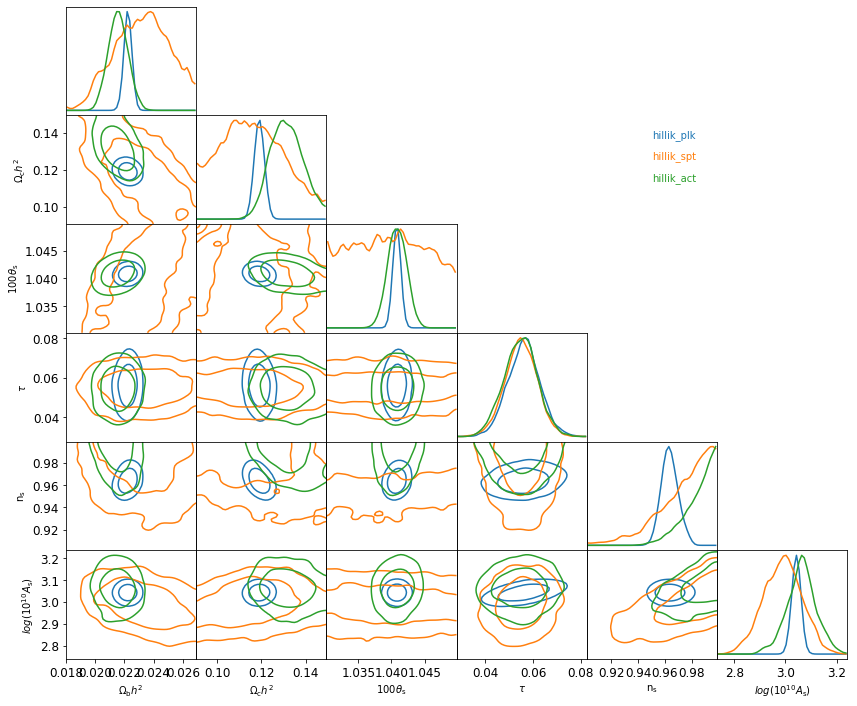

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)
print( "%35s %26s %26s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

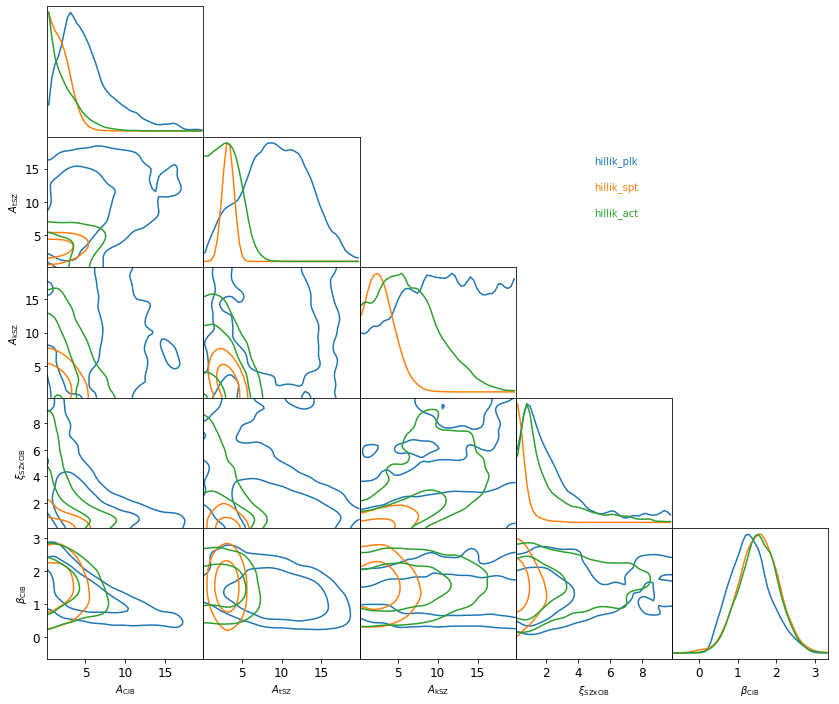

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [9]:
runnames = ['hillik_plk','hillik_plkspt','hillik_plkact','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

hillik_plk: 118360  79193  88571  89170 
hillik_plkspt: 200829  190137  145354  182017 
hillik_plkact: 192329  276401  230528  268388 
hillik_plksptact: 239342  384944  279802  241660 


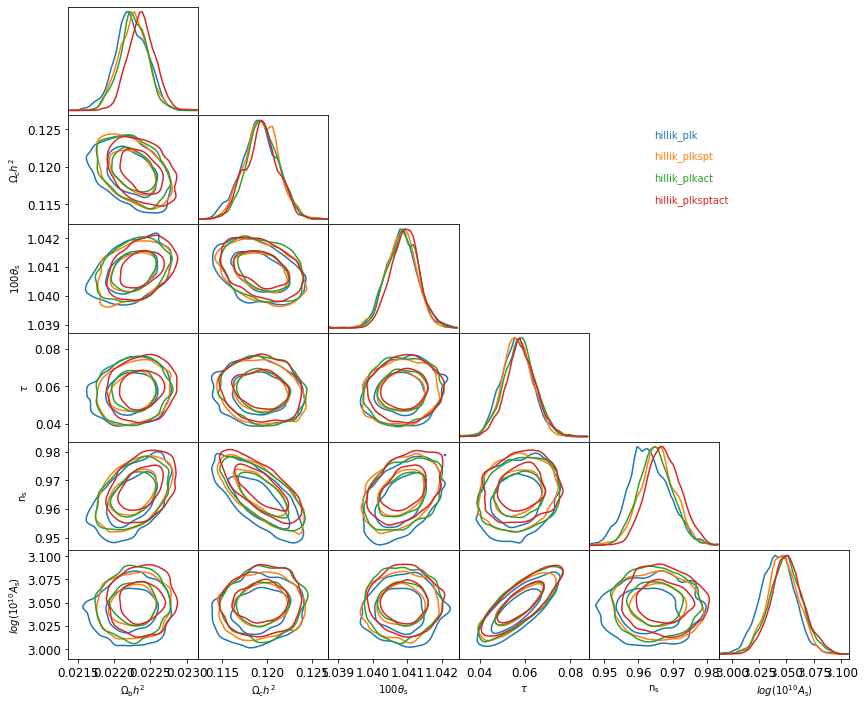

In [12]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [13]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk                hillik_plkspt                hillik_plkact             hillik_plksptact
ombh2           =  0.022225 +/- 0.000224  |   0.022269 +/- 0.000200  |   0.022268 +/- 0.000188  |   0.022379 +/- 0.000190
omch2           =  0.119155 +/- 0.002043  |   0.119390 +/- 0.001889  |   0.119491 +/- 0.001801  |   0.119430 +/- 0.001960
theta           =  1.040829 +/- 0.000450  |   1.040838 +/- 0.000429  |   1.040875 +/- 0.000446  |   1.040947 +/- 0.000401
tau             =  0.056224 +/- 0.007056  |   0.056531 +/- 0.006515  |   0.057723 +/- 0.006970  |   0.058010 +/- 0.006676
ns              =  0.962697 +/- 0.005997  |   0.965555 +/- 0.005267  |   0.964898 +/- 0.004970  |   0.967269 +/- 0.005018
logA            =  3.041837 +/- 0.015012  |   3.046446 +/- 0.013828  |   3.049144 +/- 0.014714  |   3.050575 +/- 0.014250


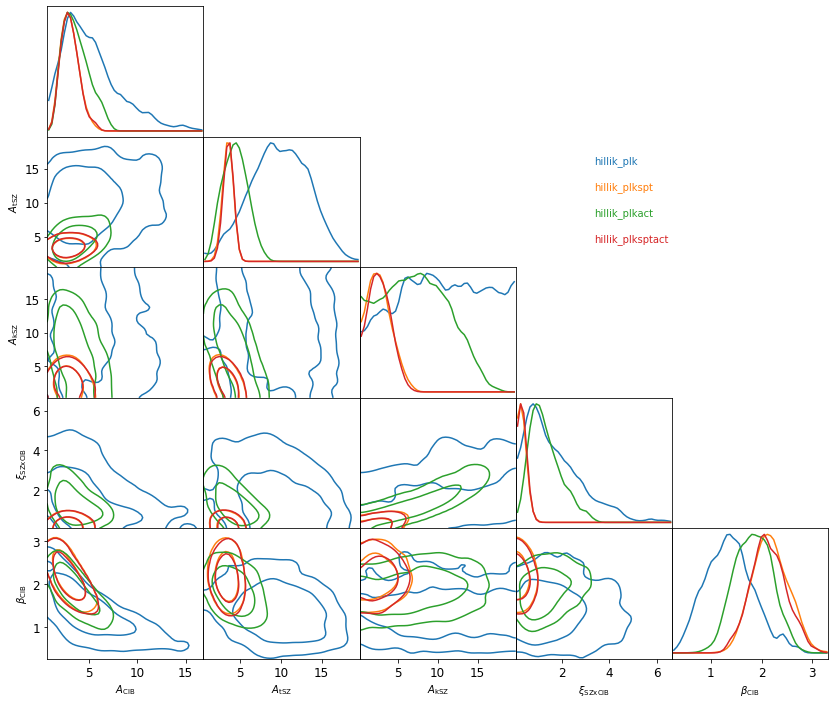

In [14]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [10]:
runnames = ['hillik_plk_Alens','hillik_plkact_Alens','hillik_plkspt_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

hillik_plk_Alens: 78965  168303  113972  113391 
hillik_plkact_Alens: 654743  532762  523340  469983 
hillik_plkspt_Alens: 386293  316674  436332  420093 
hillik_plksptact_Alens: 512309  400842  432617  493861 


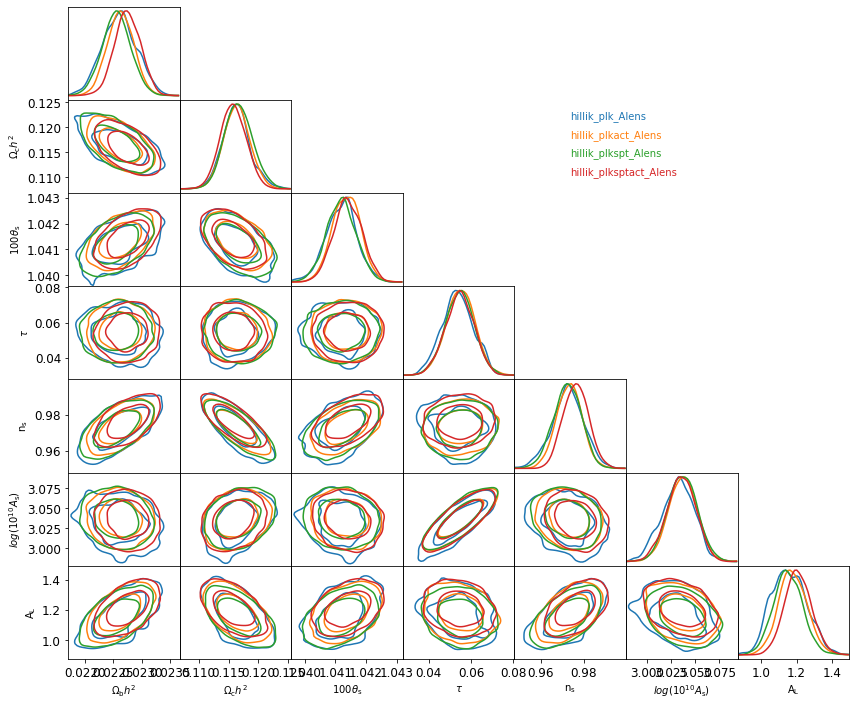

In [11]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames, smooth=1.5)

In [12]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                   hillik_plk_Alens          hillik_plkact_Alens          hillik_plkspt_Alens       hillik_plksptact_Alens
ombh2           =  0.022607 +/- 0.000318  |   0.022624 +/- 0.000234  |   0.022552 +/- 0.000249  |   0.022749 +/- 0.000231
omch2           =  0.116260 +/- 0.002179  |   0.116404 +/- 0.002154  |   0.116666 +/- 0.002328  |   0.115778 +/- 0.002151
theta           =  1.041223 +/- 0.000495  |   1.041367 +/- 0.000442  |   1.041185 +/- 0.000479  |   1.041397 +/- 0.000465
tau             =  0.053615 +/- 0.007799  |   0.055112 +/- 0.006688  |   0.054831 +/- 0.006696  |   0.054684 +/- 0.006927
ns              =  0.972664 +/- 0.007172  |   0.973402 +/- 0.005742  |   0.972449 +/- 0.006503  |   0.976363 +/- 0.005784
logA            =  3.032767 +/- 0.017535  |   3.037285 +/- 0.014917  |   3.037196 +/- 0.015230  |   3.035800 +/- 0.015403
Alens           =  1.154669 +/- 0.099935  |   1.176543 +/- 0.076631  |   1.149594 +/- 0.078053  |   1.206007 +/- 0.072386


In [13]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.155 +/- 0.100 (1.55σ) hillik_plk_Alens
1.177 +/- 0.077 (2.30σ) hillik_plkact_Alens
1.150 +/- 0.078 (1.92σ) hillik_plkspt_Alens
1.206 +/- 0.072 (2.85σ) hillik_plksptact_Alens


## Impact of Hillik

In [14]:
runnames = ['plk_spt_act','hillik_plksptact','plk_spt_act_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

plk_spt_act: 244322  223773  177833  184030 
hillik_plksptact: 587828  771558  597933  509890 
plk_spt_act_Alens: 156413  102079  170540  187353 
hillik_plksptact_Alens: 514329  402116  434300  495656 


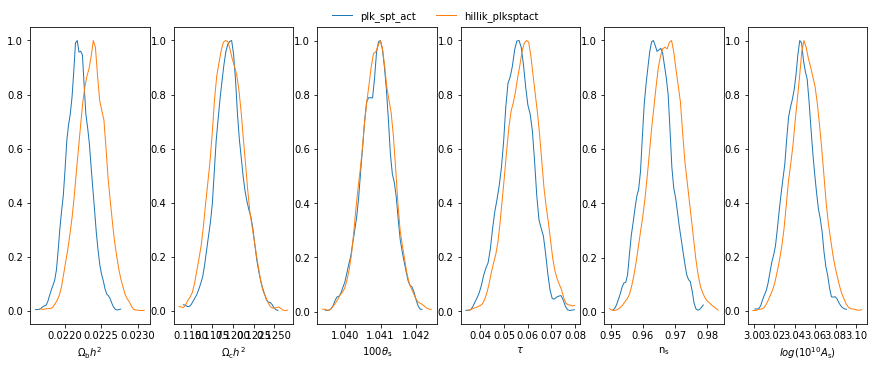

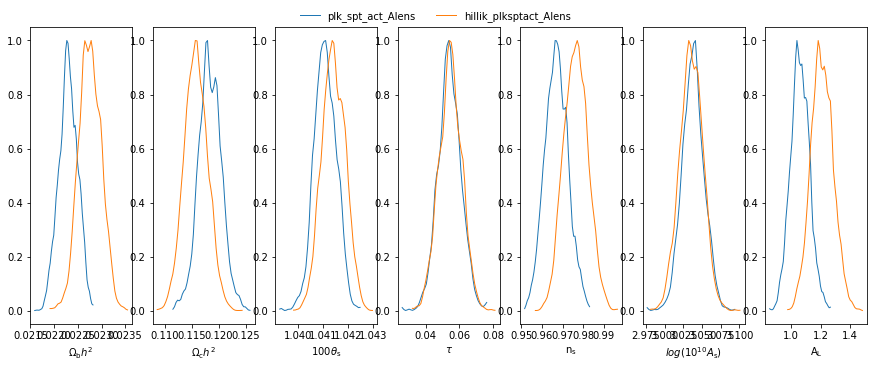

In [15]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.posterior1d( chains[:2], listpar[:-1], labels=runnames[:2], ncol=1, figsize=(15,5))
fig=MCtools.posterior1d( chains[2:], listpar, labels=runnames[2:], ncol=1, figsize=(15,5))

In [16]:
for i in range(2,len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.058 +/- 0.064 (0.91σ) plk_spt_act_Alens
1.208 +/- 0.073 (2.84σ) hillik_plksptact_Alens
